In [40]:
import os

os.chdir("..")
os.chdir("..")
os.chdir("..")
os.chdir("..")

!dir

Aula\ pos.ipynb			dsa_computer_vision  pos_visão_computacional
Case\ 1\ copy.png		dsa_math_to_AI	     projetos
Case\ 1.png			leetcode	     requirements.txt
cambridge_dictionary_data.json	libs		     web_screaping
data				notekooks


In [2]:
!dir

3.Transformações_de_intensedade_e_filtragem_espacial.ipynb  image2.png
exercicios.ipynb					    image3.png
image1.png						    image4.png


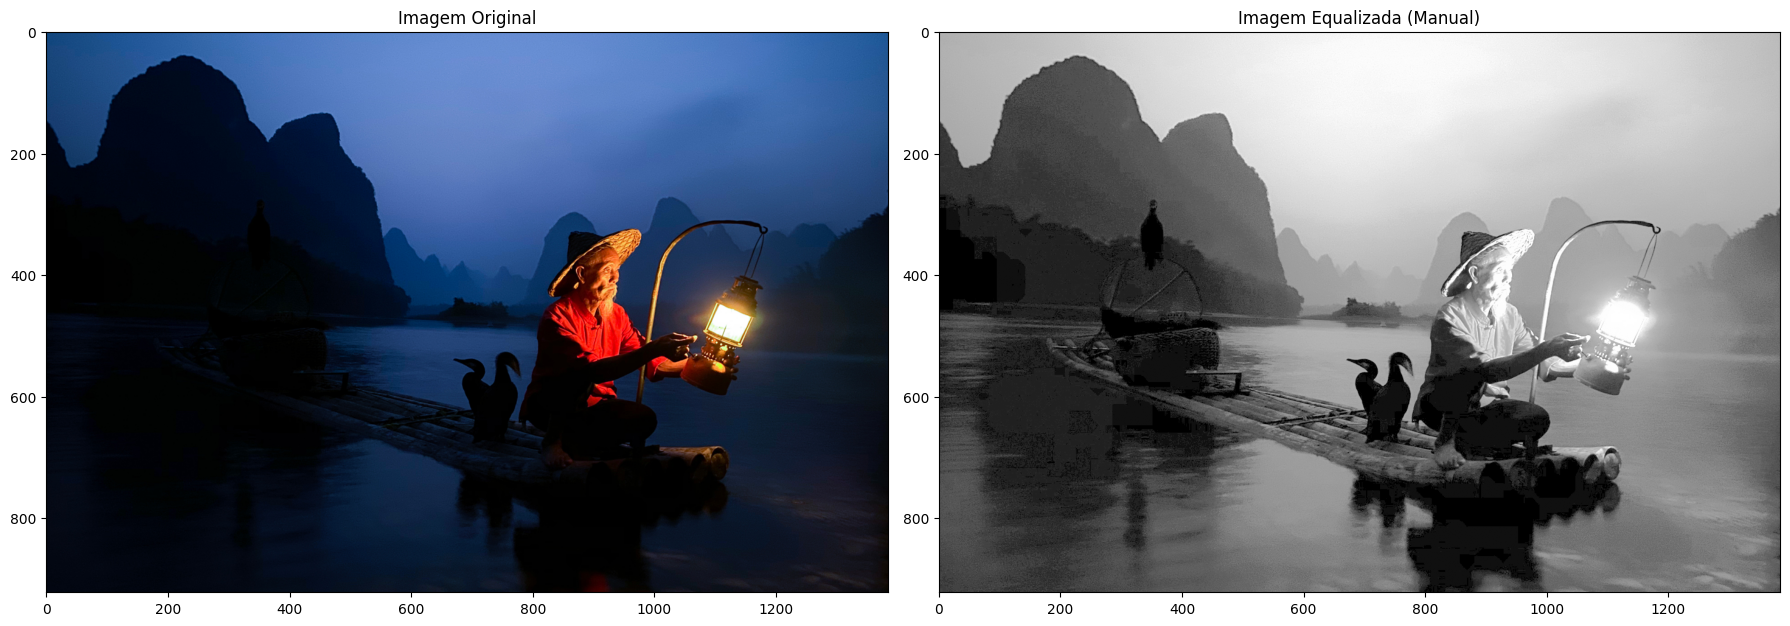

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Carregue uma imagem que precise de realce de contraste
# Muitas imagens de exemplo de PDI são boas para isso.
# Se não tiver uma, pode usar esta URL:
# url = 'https://www.researchgate.net/profile/Jose-Barbosa-Filho/publication/279213139/figure/fig1/AS:613932753367040@1523384381832/Figura-1-Imagem-original-de-Lena-a-em-tons-de-cinza-b-histograma-da-imagem-a.png'
# !wget {url} -O lena.png
# imagem = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)

path = "data/images/image1.png"
# Vamos criar uma imagem "lavada" para o exemplo
original = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
# original1 = cv2.imread('image1.png', cv2.COLOR_BGR2RGB)
original1 = Image.open(path)
if original is None:
    # Cria uma imagem sintética se nenhuma for carregada
    x = np.arange(256, dtype=np.uint8)
    y = np.sin(np.linspace(0, np.pi, 256)) * 80 + 80  # Gera valores concentrados no meio
    original = np.uint8([y for _ in x])


# --- Implementação Manual da Equalização ---

# 1. Calcular o histograma
# O resultado é um array de 256 posições, onde cada posição é a contagem de pixels
hist, bins = np.histogram(original.flatten(), 256, [0, 256])

# 2. Calcular a CDF
# A CDF é a soma cumulativa do histograma
cdf = hist.cumsum()

# 3. Normalizar a CDF para que os valores fiquem entre 0 e 1
cdf_normalizada = cdf * hist.max() / cdf.max() # Usado para o plot
cdf_mapeamento = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min()) # Fórmula da LUT
cdf_mapeamento = cdf_mapeamento.astype('uint8') # Converte para inteiros de 8 bits

# 4. Mapear os valores da imagem original para os novos valores
    # Quando fazemos cdf_mapeamento[original] basicamente estamos pegando o 
        # pixel antigo presente no "original" e substituindo por um novo, 
        # presente em "cdf_mapeamento"
    # O cdf_mapeamento contem 256 valores de 0 a 255 que representam os pixels 
        # normalizados (devidamente equalizado)

imagem_equalizada = cdf_mapeamento[original]


# --- A forma fácil com OpenCV (para comparação) ---
imagem_equalizada_cv = cv2.equalizeHist(original)


# --- Visualização ---
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

axs[0].imshow(original1, cmap='gray')
axs[0].set_title('Imagem Original')


hist_equalizado, bins_eq = np.histogram(imagem_equalizada.flatten(), 256, [0,256])
axs[1].imshow(imagem_equalizada, cmap='gray')
axs[1].set_title('Imagem Equalizada (Manual)')
plt.tight_layout()
plt.show()

In [ ]:
# --- Implementação Manual da Equalização ---

# 1. Calcular o histograma
# O resultado é um array de 256 posições, onde cada posição é a contagem de pixels
hist, bins = np.histogram(original.flatten(), bins=256, range=[0, 256])

# 2. Calcular a CDF
# A CDF é a soma cumulativa do histograma
cdf = hist.cumsum()

# 3. Normalizar a CDF para que os valores fiquem entre 0 e 1
cdf_normalizada = cdf * hist.max() / cdf.max() # Usado para o plot
cdf_mapeamento = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min()) # Fórmula da LUT
cdf_mapeamento = cdf_mapeamento.astype('uint8') # Converte para inteiros de 8 bits

# 4. Mapear os valores da imagem original para os novos valores
    # Quando fazemos cdf_mapeamento[original] basicamente estamos pegando o 
        # pixel antigo presente no "original" e substituindo por um novo, 
        # presente em "cdf_mapeamento"
    # O cdf_mapeamento contem 256 valores de 0 a 255 que representam os pixels 
        # normalizados (devidamente equalizado)
imagem_equalizada = cdf_mapeamento[original]

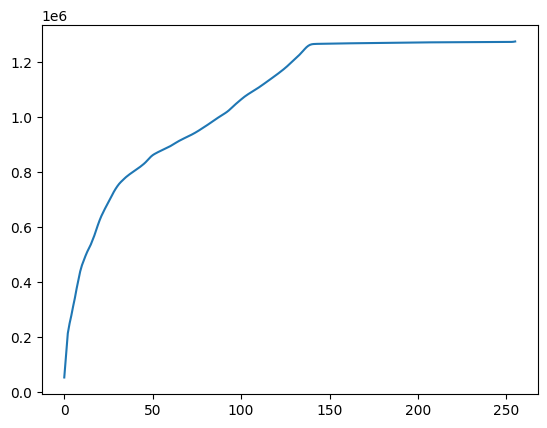

In [93]:
plt.plot(cdf)

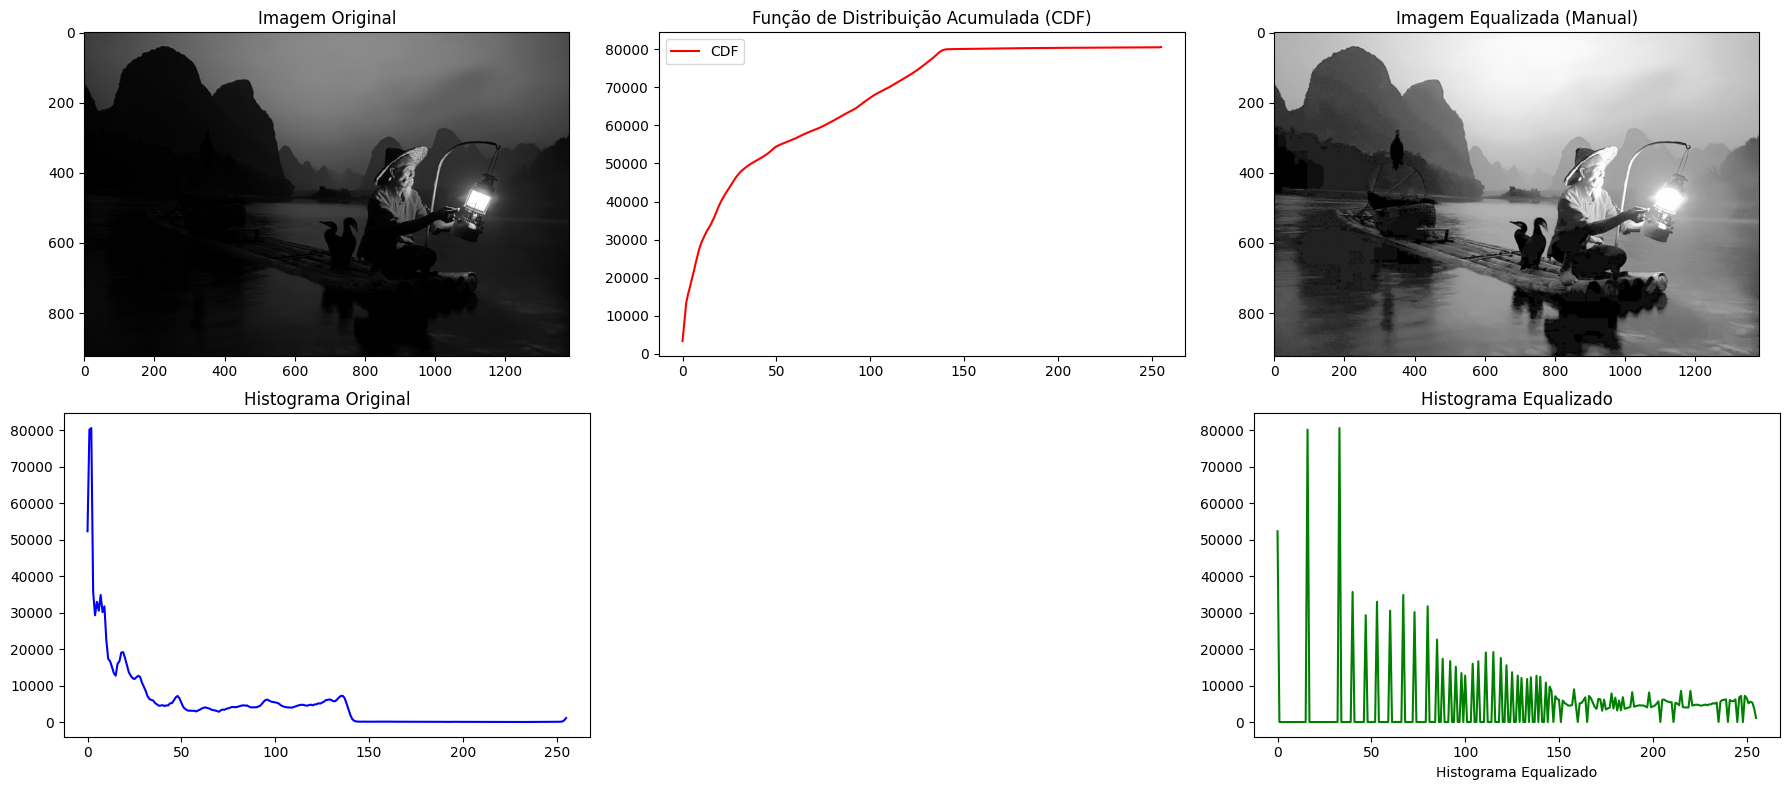

In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregue uma imagem que precise de realce de contraste
# Muitas imagens de exemplo de PDI são boas para isso.
# Se não tiver uma, pode usar esta URL:
# url = 'https://www.researchgate.net/profile/Jose-Barbosa-Filho/publication/279213139/figure/fig1/AS:613932753367040@1523384381832/Figura-1-Imagem-original-de-Lena-a-em-tons-de-cinza-b-histograma-da-imagem-a.png'
# !wget {url} -O lena.png
# imagem = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)

# Vamos criar uma imagem "lavada" para o exemplo
original = cv2.imread('data/images/image1.png', cv2.IMREAD_GRAYSCALE)
if original is None:
    # Cria uma imagem sintética se nenhuma for carregada
    x = np.arange(256, dtype=np.uint8)
    y = np.sin(np.linspace(0, np.pi, 256)) * 80 + 80  # Gera valores concentrados no meio
    original = np.uint8([y for _ in x])


# --- Implementação Manual da Equalização ---

# 1. Calcular o histograma
# O resultado é um array de 256 posições, onde cada posição é a contagem de pixels
hist, bins = np.histogram(original.flatten(), 256, [0, 256])

# 2. Calcular a CDF
# A CDF é a soma cumulativa do histograma
cdf = hist.cumsum()

# 3. Normalizar a CDF para que os valores fiquem entre 0 e 1
cdf_normalizada = cdf * hist.max() / cdf.max() # Usado para o plot
cdf_mapeamento = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min()) # Fórmula da LUT
cdf_mapeamento = cdf_mapeamento.astype('uint8') # Converte para inteiros de 8 bits

# 4. Mapear os valores da imagem original para os novos valores
imagem_equalizada = cdf_mapeamento[original]


# --- A forma fácil com OpenCV (para comparação) ---
imagem_equalizada_cv = cv2.equalizeHist(original)


# --- Visualização ---
fig, axs = plt.subplots(2, 3, figsize=(18, 8))

# Imagem Original e seu Histograma
axs[0, 0].imshow(original, cmap='gray')
axs[0, 0].set_title('Imagem Original')
axs[1, 0].plot(hist, color='b')
axs[1, 0].set_title('Histograma Original')

# Plot da CDF
axs[0, 1].plot(cdf_normalizada, color='r')
axs[0, 1].set_title('Função de Distribuição Acumulada (CDF)')
axs[0, 1].legend(('CDF',), loc='upper left')

# Imagem Equalizada e seu Histograma
hist_equalizado, bins_eq = np.histogram(imagem_equalizada.flatten(), 256, [0,256])
axs[0, 2].imshow(imagem_equalizada, cmap='gray')
axs[0, 2].set_title('Imagem Equalizada (Manual)')
axs[1, 2].plot(hist_equalizado, color='g')
axs[1, 2].set_title('Histograma Equalizado')
axs[1, 2].set_xlabel('Histograma Equalizado')

# Esconder o plot do meio da segunda linha que não será usado
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [121]:
from collections import Counter

count_freq_hist = Counter(hist_equalizado)

Text(0.5, 1.0, 'Imagem Equalizada')

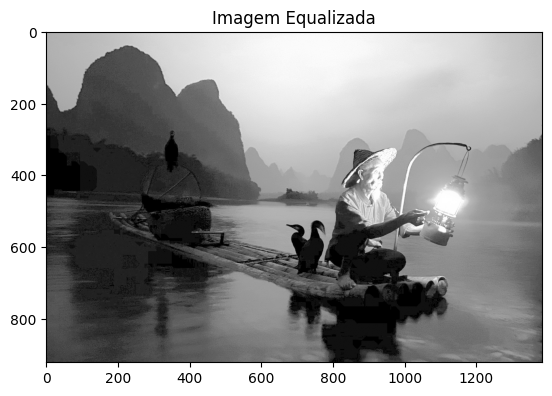

In [167]:
plt.imshow(imagem_equalizada,  cmap='gray')
# plt.hist(hist_equalizado.T, bins=256)
# plt.bar(x=count_freq_hist.values(), height=count_freq_hist.keys())
list_value_pixels = range(0, len(hist_equalizado))
# plt.bar(x=list_value_pixels, height=hist_equalizado, width=1,  color='g')
# plt.bar(x=list_value_pixels, height=hist_equalizado, width=1)
plt.title("Imagem Equalizada")
# plt.xlabel("Valores de Pixels")
# plt.ylabel("Frequencia de Pixels")

In [85]:
cdf_mapeamento.shape

(256,)

In [67]:
original[0]

array([63, 63, 61, ..., 75, 79, 76], dtype=uint8)

In [91]:
np.array([[1, 2, 3], [1, 3, 4]]).cumsum()

array([ 1,  3,  6,  7, 10, 14])

In [79]:
cdf_mapeamento[[1, 2, 3, 4]]

array([16, 33, 40, 47], dtype=uint8)

In [63]:
# Achatando a imagem em um unico vetor
image_flatten = original.flatten()

# Criando a frequencia com que os dados aparecem na imagem achatada
hist, bins = np.histogram(image_flatten, bins=256, range=[0, 256])


Text(0, 0.5, 'Frequencia')

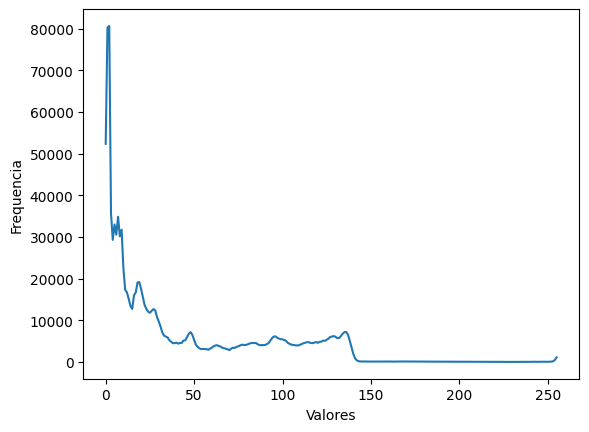

In [64]:
plt.plot(hist)
plt.xlabel("Valores")
plt.ylabel("Frequencia")

In [59]:
hist

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [225]:

# soma_acumulada = 0
# lista_numeros = [0, 0.19,0.25,0.21,0.16,0.08,0.06,0.03,0.02, 0,]
# # lista_numeros = [0.12,0.16,0.16,0.03,0.19,0.25,0.06,0.03]


# for idx, i in enumerate(lista_numeros):
#     soma_acumulada += i

#     print(f"{i} + {lista_numeros[idx+1]} = {round(soma_acumulada, 2)}")

In [229]:
import numpy as np

# Nossos dados iniciais
nk = np.array([8, 10, 10, 2, 12, 16, 4, 2])
MN = 64
L = 8

# PDF
pdf = nk / MN

# CDF
cdf = np.cumsum(pdf)

# Mapeamento e arredondamento
sk = (L - 1) * cdf
sk_arredondado = np.round(sk).astype(int)

print("--- Verificação com Código ---")
print("Dados Iniciais (nk):", nk)
print("PDF:", np.round(pdf, 2))
print("CDF:", np.round(cdf, 2))
print("Valores sk (antes de arredondar):", np.round(sk, 2))
print("\n--- Tabela de Mapeamento Final ---")
print("Valores sk (arredondados):", sk_arredondado)

--- Verificação com Código ---
Dados Iniciais (nk): [ 8 10 10  2 12 16  4  2]
PDF: [0.12 0.16 0.16 0.03 0.19 0.25 0.06 0.03]
CDF: [0.12 0.28 0.44 0.47 0.66 0.91 0.97 1.  ]
Valores sk (antes de arredondar): [0.88 1.97 3.06 3.28 4.59 6.34 6.78 7.  ]

--- Tabela de Mapeamento Final ---
Valores sk (arredondados): [1 2 3 3 5 6 7 7]


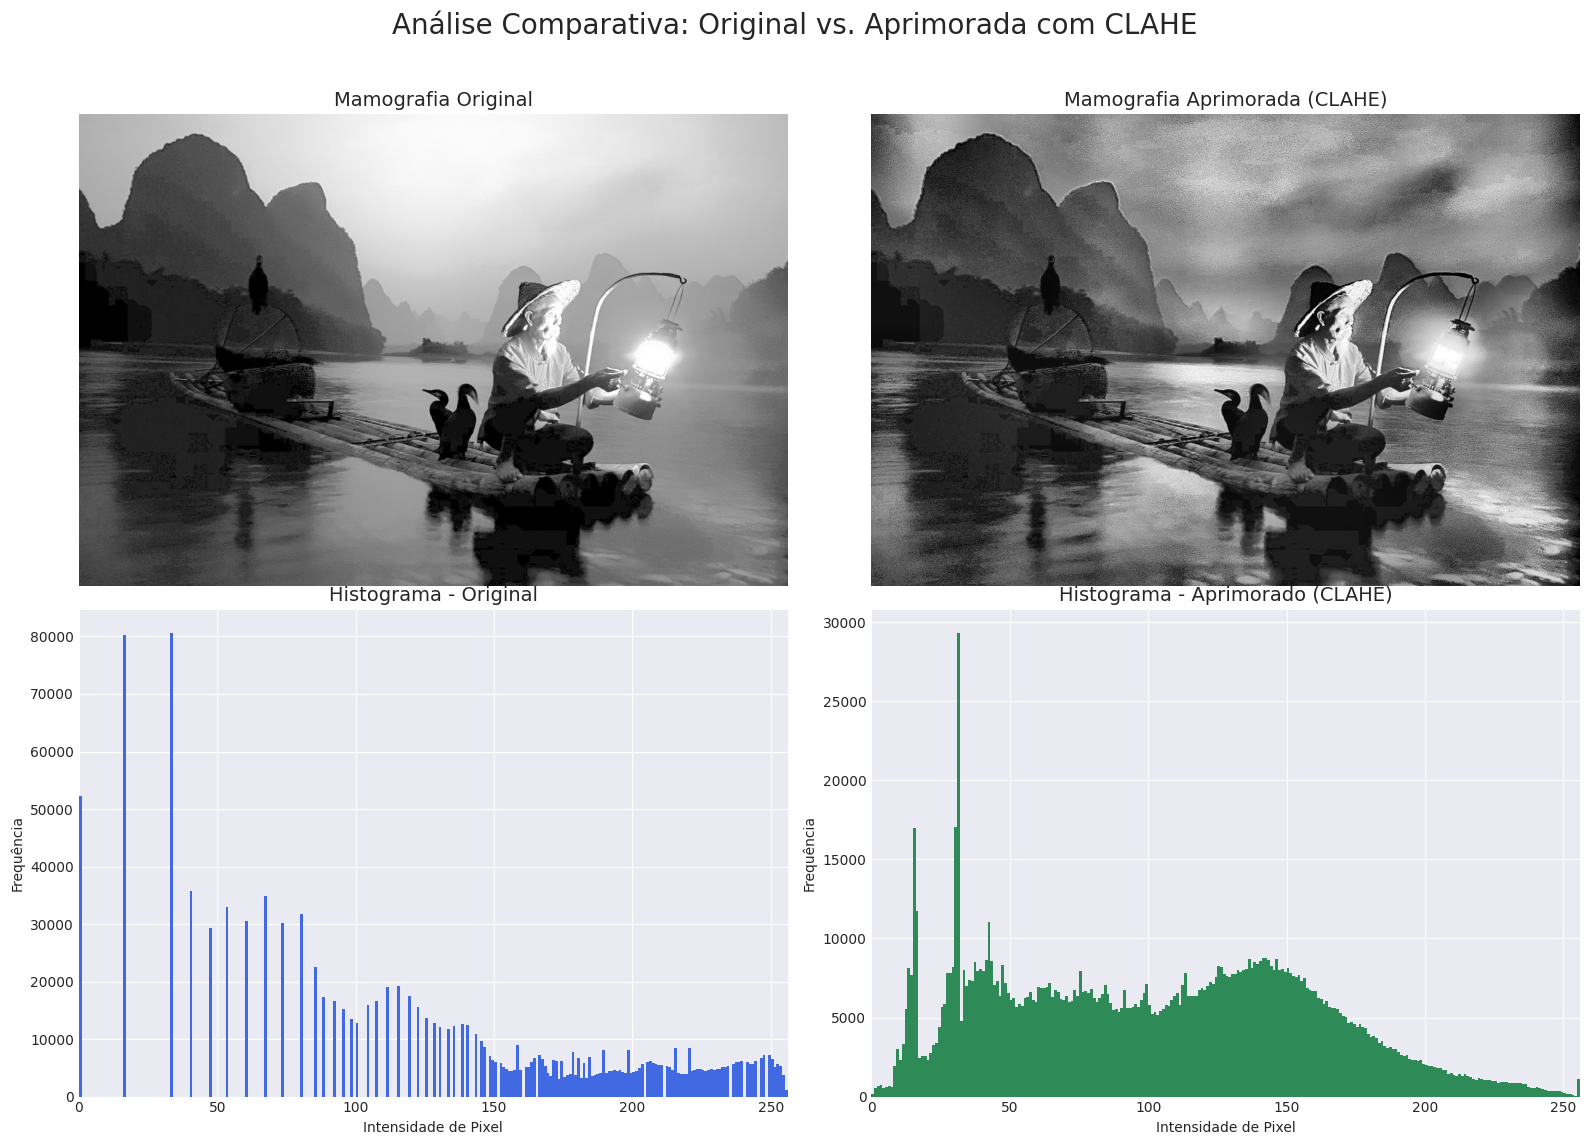

In [207]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Definindo um estilo visual mais agradável para os plots
plt.style.use('seaborn-v0_8-darkgrid')

def aprimorar_mamografia_com_clahe(caminho_imagem: str, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)):
    """
    Aplica a técnica CLAHE para aprimorar a visibilidade em uma imagem de mamografia.

    Args:
        caminho_imagem (str): O caminho para o arquivo de imagem original.
        clip_limit (float): Limite para a amplificação de contraste. Valores mais altos
                            resultam em maior contraste. 2.0 é um bom ponto de partida.
        tile_grid_size (tuple): O tamanho da grade para a equalização adaptativa.

    Returns:
        tuple[np.ndarray, np.ndarray]: Uma tupla contendo a imagem original e a imagem aprimorada.
    """
    # Carrega a imagem em escala de cinza.
    # Imagens médicas como mamografias são inerentemente monocromáticas.
    imagem_original = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if imagem_original is None:
        raise FileNotFoundError(f"Erro: Imagem não encontrada no caminho: {caminho_imagem}")

    # Cria o objeto CLAHE com os parâmetros definidos.
    # O clipLimit controla a amplificação de ruído.
    # O tileGridSize define as janelas locais para a análise.
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    # Aplica o CLAHE na imagem original.
    imagem_aprimorada = clahe.apply(imagem_original)

    return imagem_original, imagem_aprimorada

def visualizar_comparacao(original: np.ndarray, aprimorada: np.ndarray):
    """
    Exibe a imagem original e a aprimorada lado a lado, com seus respectivos histogramas.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise Comparativa: Original vs. Aprimorada com CLAHE', fontsize=20)

    # Imagem Original
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Mamografia Original', fontsize=14)
    axes[0, 0].axis('off')

    # Histograma da Imagem Original
    axes[1, 0].hist(original.ravel(), bins=256, range=[0, 256], color='royalblue')
    axes[1, 0].set_title('Histograma - Original', fontsize=14)
    axes[1, 0].set_xlabel('Intensidade de Pixel')
    axes[1, 0].set_ylabel('Frequência')
    axes[1, 0].set_xlim([0, 256])

    # Imagem Aprimorada
    axes[0, 1].imshow(aprimorada, cmap='gray')
    axes[0, 1].set_title('Mamografia Aprimorada (CLAHE)', fontsize=14)
    axes[0, 1].axis('off')

    # Histograma da Imagem Aprimorada
    axes[1, 1].hist(aprimorada.ravel(), bins=256, range=[0, 256], color='seagreen')
    axes[1, 1].set_title('Histograma - Aprimorado (CLAHE)', fontsize=14)
    axes[1, 1].set_xlabel('Intensidade de Pixel')
    axes[1, 1].set_ylabel('Frequência')
    axes[1, 1].set_xlim([0, 256])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


if __name__ == '__main__':
    # --- Ponto de Execução ---
    # Para usar, substitua 'caminho/para/sua/mamografia.png' pelo caminho real do arquivo.
    # Como não temos a imagem, vamos criar uma imagem de exemplo que simula o problema.
    # def criar_mamografia_simulada(nome_arquivo='Case 1.png'):
    #     # Cria uma imagem com baixo contraste geral e algumas áreas claras/escuras
    #     img = np.full((512, 512), 128, dtype=np.uint8)
    #     # Adiciona uma região de tecido denso (um pouco mais clara)
    #     cv2.rectangle(img, (100, 100), (400, 400), 150, -1)
    #     # Adiciona "calcificações" sutis (pequenos pontos brilhantes)
    #     for _ in range(30):
    #         x, y = np.random.randint(150, 350, 2)
    #         cv2.circle(img, (x, y), 2, 165, -1) # Contraste muito baixo
    #     # Adiciona ruído gaussiano para simular a textura da imagem
    #     ruido = np.zeros(img.shape, np.uint8)
    #     cv2.randn(ruido, 0, 10)
    #     img = cv2.add(img, ruido)
    #     cv2.imwrite(nome_arquivo, img)
    #     return nome_arquivo

    # caminho_da_imagem = criar_mamografia_simulada()

    try:
        # Processa a imagem
        img_original, img_aprimorada = aprimorar_mamografia_com_clahe(
            path, 
            clip_limit= 15.0,
            tile_grid_size= (8, 8))
        # Visualiza os resultados
        # visualizar_comparacao(img_original, img_aprimorada)
        # img_aprimorada = img_aprimorada * 100.1
        visualizar_comparacao(imagem_equalizada, img_aprimorada)
    except FileNotFoundError as e:
        print(e)